<a href="https://colab.research.google.com/github/drmistretta/PredictCollege/blob/main/Descriptive_Mean_Median_and_Model_of_SRL_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


+----------------------------------+----------------------------------------------+--------+----------+
| Feature                          | Label                                        |   Mean |   Median |
+==================================+==============================================+========+==========+
| H5PE7                            | I finish whatever I begin.                   |   2.18 |        2 |
+----------------------------------+----------------------------------------------+--------+----------+
| H5PE8                            | I am a hard worker.                          |   1.84 |        2 |
+----------------------------------+----------------------------------------------+--------+----------+
| H5PE9                            | I am diligent. I never give up.              |   1.95 |        2 |
+----------------------------------+----------------------------------------------+--------+----------+
| H5PE1                            | I am always optimistic abou

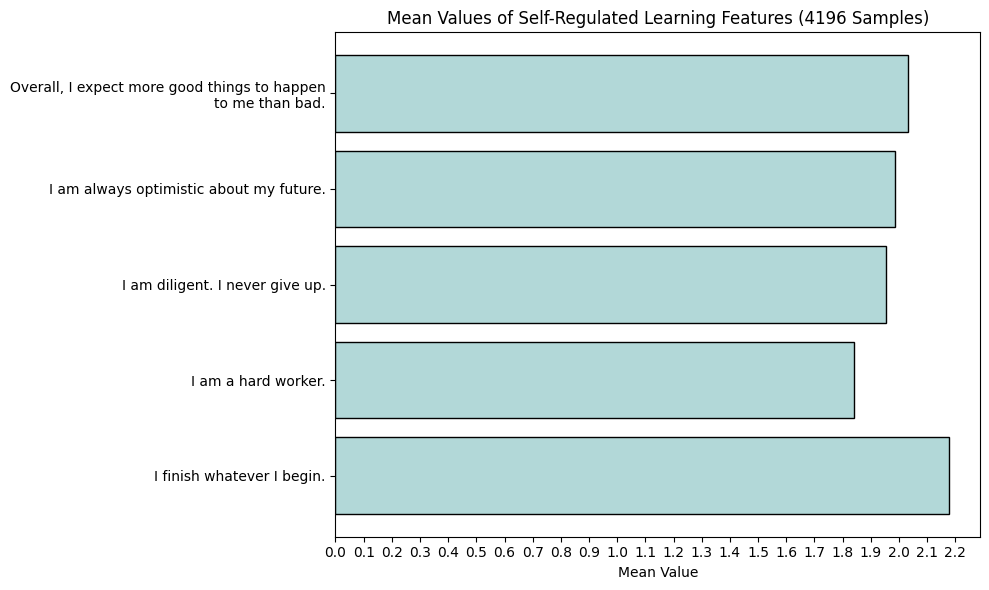

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from tabulate import tabulate

# The DataFrame is named df and the columns of interest are H5PE7, H5PE8, H5PE9, H5PE1, and H5PE3
# Load the dataset
df = pd.read_csv('/content/drive/Shared drives/Dr. Sharon Mistretta/Add Health/Predict_College/data_with_birth_year.csv')

# List of Self-Regulated Learning Features
srl_features = ['H5PE7', 'H5PE8', 'H5PE9', 'H5PE1', 'H5PE3']

# Define the number of features, this can be updated if more features are added
number_of_features = len(srl_features)

# Define labels for each feature
labels = {
    'H5PE7': "I finish whatever I begin.",
    'H5PE8': "I am a hard worker.",
    'H5PE9': "I am diligent. I never give up.",
    'H5PE1': "I am always optimistic about my future.",
    'H5PE3': "Overall, I expect more good things to happen\nto me than bad."
}

# Prepare the list to store the results for tabulate and chart data
table_data = []
mean_values = []  # For storing mean values of each SRL feature
feature_labels = []  # For storing feature labels

# Loop through each feature to calculate mean and median for individual features and add labels
for feature in srl_features:
    mean_value = df[feature].mean()
    median_value = df[feature].median()
    label = labels.get(feature, '')  # Get the corresponding label

    # Append the results for this feature as a row in the table, rounded to two decimal places
    table_data.append([feature, label, round(mean_value, 2), round(median_value, 2)])

    # Store mean values and labels for the bar chart
    mean_values.append(mean_value)
    feature_labels.append(label)  # Now using label (a string) for the feature

# Create SRL value for each sample by summing the SRL features for each row
df['SRL_Value'] = df[srl_features].sum(axis=1)

# Calculate overall mean and median for the SRL_Value column
overall_mean = df['SRL_Value'].mean() / number_of_features  # Use number_of_features instead of hardcoding
overall_median = df['SRL_Value'].median() / number_of_features

# Calculate the number of samples (rows) in the DataFrame
number_of_samples = df.shape[0]

# Add overall results to the table at the bottom for the SRL value, rounding to two decimal places
table_data.append([f'Overall SRL Value ({number_of_samples} Samples)', '', round(overall_mean, 2), round(overall_median, 2)])

# Define the headers for the table (with the Label column)
headers = ['Feature', 'Label', 'Mean', 'Median']

# Generate the table using tabulate
table = tabulate(table_data, headers, tablefmt="grid")

# Display the table
print(table)

# Function to format the y-axis labels as tenths
def format_tenths(x, pos):
    return f'{x:.1f}'  # Format the label with one decimal place

# Plotting the bar chart for SRL feature means
plt.figure(figsize=(10, 6))
plt.barh(feature_labels, mean_values, color='#b2d8d8', edgecolor='black')  # Adds a black border to each bar
plt.xlabel('Mean Value')
plt.title(f'Mean Values of Self-Regulated Learning Features ({number_of_samples} Samples)')

# Set the x-axis to show tenths (0.0, 0.1, 0.2, etc.)
plt.xticks(np.arange(0, max(mean_values) + 0.1, 0.1))  # Set ticks at 0.1 intervals

plt.tight_layout()

# Show the bar chart
plt.show()
